In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GroupKFold, cross_val_predict

cat_final, num_final = cat_small, num
cols_final = cat_final + num_final

oof = cross_val_predict(make_model(cat_final, num_final),
                        tr[cols_final], tr["at_risk"],
                        groups=tr["id_student"], cv=GroupKFold(n_splits=5),
                        method="predict_proba")[:, 1]
y = tr["at_risk"].values
rows = []
for t in np.arange(0.20, 0.65, 0.05):
    t = round(float(t), 2)
    pr = (oof >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y, pr),
                 "recall": recall_score(y, pr), "f1": f1_score(y, pr),
                 "share_flagged": pr.mean()})
tbl = pd.DataFrame(rows).round(3)
print(tbl.to_string(index=False))
best_t = float(tbl.loc[tbl["f1"].idxmax(), "threshold"])
print("threshold with best F1:", best_t)

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

ROOT = Path(r"C:\Users\Robin Yadav\oulad-early-warning")
RAW = ROOT / "data" / "raw"
key = ["code_module", "code_presentation", "id_student"]

info = pd.read_csv(RAW / "studentInfo.csv")
reg = pd.read_csv(RAW / "studentRegistration.csv")
assess = pd.read_csv(RAW / "assessments.csv")
sa = pd.read_csv(RAW / "studentAssessment.csv")
clicks = pd.read_csv(
    RAW / "studentVle.csv",
    dtype={"code_module": "category", "code_presentation": "category",
           "id_student": "int32", "id_site": "int32",
           "date": "int16", "sum_click": "int32"},
)
print("loaded", clicks.shape)

loaded (10655280, 6)


In [13]:
def build(cutoff):
    df = info.merge(reg, on=key, how="left", validate="one_to_one")
    df["at_risk"] = df["final_result"].isin(["Withdrawn", "Fail"]).astype(int)
    left = df["date_unregistration"].notna() & (df["date_unregistration"] <= cutoff)
    df = df[~left].drop(columns=["date_unregistration", "final_result"])

    c = clicks[clicks["date"] <= cutoff]
    half = cutoff // 2
    c = c.assign(period=np.select([c["date"] < 0, c["date"] < half],
                                  ["pre", "early"], "late"))
    g = c.groupby(key, observed=True).agg(
        total_clicks=("sum_click", "sum"), active_days=("date", "nunique"),
        n_sites=("id_site", "nunique"), last_active_day=("date", "max")).reset_index()
    p = (c.groupby(key + ["period"], observed=True)["sum_click"].sum()
           .unstack(fill_value=0).reset_index())
    for col in ["pre", "early", "late"]:
        if col not in p.columns:
            p[col] = 0
    p = p.rename(columns={"pre": "clicks_pre", "early": "clicks_early", "late": "clicks_late"})
    cf = g.merge(p, on=key, how="left")
    for col in ["code_module", "code_presentation"]:
        cf[col] = cf[col].astype(str)
    cf["click_trend"] = cf["clicks_late"] - cf["clicks_early"]
    cf["days_since_last_active"] = cutoff - cf["last_active_day"]
    cf = cf.drop(columns="last_active_day")

    due = assess[assess["date"].notna() & (assess["date"] <= cutoff)]
    sub = sa.merge(due[["id_assessment", "code_module", "code_presentation"]], on="id_assessment")
    sub = sub[sub["date_submitted"] <= cutoff]
    a = sub.groupby(key).agg(n_submitted=("id_assessment", "nunique"),
                             mean_score=("score", "mean")).reset_index()
    n_due = (due.groupby(["code_module", "code_presentation"]).size()
                .rename("n_assessments_due").reset_index())

    f = (df.merge(cf, on=key, how="left").merge(a, on=key, how="left")
           .merge(n_due, on=["code_module", "code_presentation"], how="left"))
    zero = ["total_clicks", "active_days", "n_sites", "clicks_pre", "clicks_early",
            "clicks_late", "click_trend", "n_submitted", "n_assessments_due"]
    f[zero] = f[zero].fillna(0)
    f["days_since_last_active"] = f["days_since_last_active"].fillna(cutoff + 1)
    f["no_clicks_flag"] = (f["total_clicks"] == 0).astype(int)
    return f

cat = ["code_module", "gender", "region", "highest_education",
       "imd_band", "age_band", "disability"]
num_demo = ["num_of_prev_attempts", "studied_credits", "date_registration"]
click_cols = ["total_clicks", "active_days", "n_sites", "clicks_pre", "clicks_early",
              "clicks_late", "click_trend", "days_since_last_active", "no_clicks_flag"]
assess_cols = ["n_submitted", "mean_score", "n_assessments_due"]

def make_model(cat_cols, num_cols):
    pre = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
            ("sc", StandardScaler())]), num_cols),
    ], sparse_threshold=0)
    return Pipeline([("pre", pre), ("model", HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
        l2_regularization=1.0, early_stopping=True, random_state=42))])

# fixed test students, shared by every cutoff
ids = info["id_student"].unique()
rng = np.random.RandomState(42)
test_ids = set(rng.choice(ids, size=int(0.2 * len(ids)), replace=False))

def recall_at_top(y, proba, frac):
    k = int(len(y) * frac)
    top = np.argsort(-proba)[:k]
    return y[top].sum() / y.sum()

In [14]:
rows = []
for week, cutoff in [(2, 14), (4, 28), (6, 42), (8, 56)]:
    f = build(cutoff)
    is_test = f["id_student"].isin(test_ids)
    tr, te = f[~is_test], f[is_test]
    num = num_demo + click_cols + assess_cols
    m = make_model(cat, num).fit(tr[cat + num], tr["at_risk"])
    proba = m.predict_proba(te[cat + num])[:, 1]
    y = te["at_risk"].values
    rows.append({"week": week, "cutoff_day": cutoff, "n_test": len(te),
                 "at_risk_rate": y.mean(),
                 "roc_auc": roc_auc_score(y, proba),
                 "pr_auc": average_precision_score(y, proba),
                 "recall_top30%": recall_at_top(y, proba, 0.30),
                 "recall_top50%": recall_at_top(y, proba, 0.50)})
pd.DataFrame(rows).round(3)

,week,cutoff_day,n_test,at_risk_rate,roc_auc,pr_auc,recall_top30%,recall_top50%
0,2,14,5575,0.446,0.737,0.691,0.470,0.697
1,4,28,5454,0.434,0.786,0.755,0.521,0.734
2,6,42,5337,0.421,0.801,0.772,0.551,0.751
3,8,56,5236,0.410,0.825,0.796,0.571,0.785


In [15]:
f28 = build(28)
is_test = f28["id_student"].isin(test_ids)
tr, te = f28[~is_test], f28[is_test]
y = te["at_risk"].values

sets = {"demographics only": num_demo,
        "demographics + clicks": num_demo + click_cols,
        "demographics + assessments": num_demo + assess_cols,
        "all features": num_demo + click_cols + assess_cols}
out = []
for name, num in sets.items():
    m = make_model(cat, num).fit(tr[cat + num], tr["at_risk"])
    proba = m.predict_proba(te[cat + num])[:, 1]
    out.append({"features": name, "roc_auc": roc_auc_score(y, proba),
                "pr_auc": average_precision_score(y, proba),
                "recall_top50%": recall_at_top(y, proba, 0.50)})
pd.DataFrame(out).round(3)

,features,roc_auc,pr_auc,recall_top50%
0,demographics only,0.662,0.587,0.640
1,demographics + clicks,0.747,0.703,0.702
2,demographics + assessments,0.756,0.722,0.710
3,all features,0.786,0.755,0.734


saved: ['cutoff_comparison.csv', 'cutoff_comparison.png', 'fairness_day28.csv', 'feature_ablation.csv']


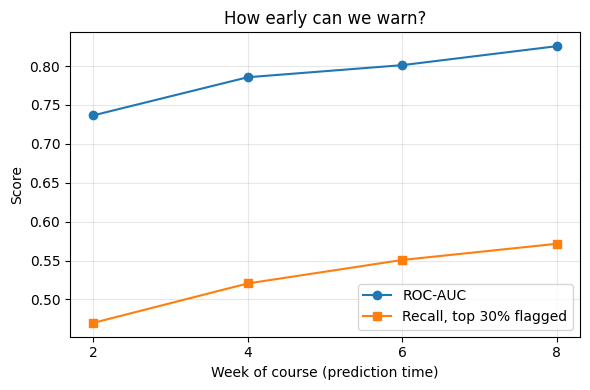

In [16]:
import matplotlib.pyplot as plt

REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

cut_df = pd.DataFrame(rows)
abl_df = pd.DataFrame(out)
cut_df.round(3).to_csv(REPORTS / "cutoff_comparison.csv", index=False)
abl_df.round(3).to_csv(REPORTS / "feature_ablation.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cut_df["week"], cut_df["roc_auc"], marker="o", label="ROC-AUC")
ax.plot(cut_df["week"], cut_df["recall_top30%"], marker="s", label="Recall, top 30% flagged")
ax.set_xticks(cut_df["week"])
ax.set_xlabel("Week of course (prediction time)")
ax.set_ylabel("Score")
ax.set_title("How early can we warn?")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS / "cutoff_comparison.png", dpi=150)
print("saved:", [p.name for p in REPORTS.iterdir()])

In [17]:
import json
MODELS = ROOT / "models"

opts = {c: sorted(f28[c].dropna().astype(str).unique().tolist()) for c in cat}
opts["defaults"] = {c: float(f28[c].median()) for c in
    ["num_of_prev_attempts", "studied_credits", "date_registration",
     "clicks_pre", "clicks_early", "clicks_late",
     "active_days", "n_sites", "days_since_last_active"]}

(MODELS / "app_options.json").write_text(json.dumps(opts, indent=2))
print({k: len(v) for k, v in opts.items() if k != "defaults"})
print(opts["defaults"])

{'code_module': 7, 'gender': 2, 'region': 13, 'highest_education': 5, 'imd_band': 10, 'age_band': 3, 'disability': 2}
{'num_of_prev_attempts': 0.0, 'studied_credits': 60.0, 'date_registration': -53.0, 'clicks_pre': 27.0, 'clicks_early': 75.0, 'clicks_late': 88.0, 'active_days': 13.0, 'n_sites': 23.0, 'days_since_last_active': 2.0}


In [18]:
THRESHOLD = 0.35

f28 = build(28)
is_test = f28["id_student"].isin(test_ids)
tr, te = f28[~is_test], f28[is_test].copy()

num = num_demo + click_cols + assess_cols
m = make_model(cat, num).fit(tr[cat + num], tr["at_risk"])
te["proba"] = m.predict_proba(te[cat + num])[:, 1]
te["flag"] = (te["proba"] >= THRESHOLD).astype(int)
print(len(te), "test rows,", round(te["flag"].mean(), 3), "flagged overall")

5454 test rows, 0.56 flagged overall


In [19]:
def group_report(col):
    rows = []
    for val, g in te.groupby(col, dropna=False):
        y, f = g["at_risk"].values, g["flag"].values
        rows.append({
            "group": f"{col}={val}",
            "n": len(g),
            "at_risk_rate": y.mean(),
            "flagged_rate": f.mean(),
            "recall": f[y == 1].sum() / max(y.sum(), 1),
            "false_alarm_rate": f[y == 0].sum() / max((1 - y).sum(), 1),
            "precision": y[f == 1].sum() / max(f.sum(), 1),
        })
    return pd.DataFrame(rows)

fair = pd.concat([group_report(c) for c in
                  ["gender", "disability", "age_band", "highest_education", "imd_band"]])
fair = fair.round(3)
print(fair.to_string(index=False))

                                        group    n  at_risk_rate  flagged_rate  recall  false_alarm_rate  precision
                                     gender=F 2472         0.426         0.544   0.754             0.388      0.591
                                     gender=M 2982         0.440         0.573   0.809             0.387      0.621
                                 disability=N 4917         0.420         0.542   0.771             0.376      0.598
                                 disability=Y  537         0.559         0.721   0.873             0.527      0.677
                                age_band=0-35 3757         0.454         0.604   0.807             0.435      0.607
                               age_band=35-55 1644         0.391         0.465   0.728             0.296      0.613
                                age_band=55<=   53         0.302         0.377   0.688             0.243      0.550
      highest_education=A Level or Equivalent 2362         0.389        

In [11]:
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
fair.to_csv(REPORTS / "fairness_day28.csv", index=False)
print("saved")

saved


In [24]:
drop_cat = ["gender", "disability", "age_band", "imd_band"]
cat_small = [c for c in cat if c not in drop_cat]
num = num_demo + click_cols + assess_cols

m2 = make_model(cat_small, num).fit(tr[cat_small + num], tr["at_risk"])
te["proba2"] = m2.predict_proba(te[cat_small + num])[:, 1]

print("ROC-AUC with all:", round(roc_auc_score(te["at_risk"], te["proba"]), 3),
      " without sensitive:", round(roc_auc_score(te["at_risk"], te["proba2"]), 3))

thr2 = np.quantile(te["proba2"], 1 - te["flag"].mean())
te["flag2"] = (te["proba2"] >= thr2).astype(int)

def gap_table(col):
    rows = []
    for val, g in te.groupby(col):
        if len(g) < 100:
            continue
        y = g["at_risk"].values
        for tag, f in [("all", g["flag"].values), ("no_sensitive", g["flag2"].values)]:
            rows.append({"group": f"{col}={val}", "model": tag,
                         "recall": f[y == 1].mean(), "false_alarm": f[y == 0].mean()})
    return pd.DataFrame(rows)

cmp = pd.concat([gap_table(c) for c in ["gender", "disability", "highest_education"]])
cmp.pivot(index="group", columns="model", values=["recall", "false_alarm"]).round(3)

ROC-AUC with all: 0.786  without sensitive: 0.782


recall              false_alarm  \
model                                      all no_sensitive         all   
group                                                                     
disability=N                             0.771        0.779       0.376   
disability=Y                             0.873        0.810       0.527   
gender=F                                 0.754        0.747       0.388   
gender=M                                 0.809        0.812       0.387   
highest_education=A Level or Equivalent  0.694        0.691       0.321   
highest_education=HE Qualification       0.670        0.674       0.248   
highest_education=Lower Than A Level     0.882        0.880       0.559   

                                                      
model                                   no_sensitive  
group                                                 
disability=N                                   0.383  
disability=Y                                   0.456  
gender=F                                       0.403  
gender=M                                       0.376  
highest_education=A Level or Equivalent        0.307  
highest_education=HE Qualification             0.253  
highest_education=Lower Than A Level           0.574

In [22]:
from sklearn.model_selection import GroupKFold, cross_val_predict

cat_final, num_final = cat_small, num
cols_final = cat_final + num_final

oof = cross_val_predict(make_model(cat_final, num_final),
                        tr[cols_final], tr["at_risk"],
                        groups=tr["id_student"], cv=GroupKFold(n_splits=5),
                        method="predict_proba")[:, 1]
y = tr["at_risk"].values
rows = []
for t in np.arange(0.20, 0.65, 0.05):
    t = round(float(t), 2)
    pr = (oof >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y, pr),
                 "recall": recall_score(y, pr), "f1": f1_score(y, pr),
                 "share_flagged": pr.mean()})
tbl = pd.DataFrame(rows).round(3)
print(tbl.to_string(index=False))
best_t = float(tbl.loc[tbl["f1"].idxmax(), "threshold"])
print("threshold with best F1:", best_t)

NameError: name 'precision_score' is not defined

In [ ]:
import shutil, joblib, json, sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

m_final = make_model(cat_final, num_final).fit(tr[cols_final], tr["at_risk"])
p = m_final.predict_proba(te[cols_final])[:, 1]
yt = te["at_risk"].values
pred = (p >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
print("ROC-AUC", round(roc_auc_score(yt, p), 3), " PR-AUC", round(average_precision_score(yt, p), 3))
print(f"threshold {best_t}: precision={precision_score(yt, pred):.3f} "
      f"recall={recall_score(yt, pred):.3f} f1={f1_score(yt, pred):.3f} flagged={pred.mean():.3f}")
print(f"TP={tp} FN={fn} FP={fp} TN={tn}")

MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
shutil.copy(MODELS / "risk_model_day28.joblib", MODELS / "risk_model_day28_v1_with_sensitive.joblib")
shutil.copy(MODELS / "model_meta.json", MODELS / "model_meta_v1.json")

deploy = make_model(cat_final, num_final).fit(f28[cols_final], f28["at_risk"])
joblib.dump(deploy, MODELS / "risk_model_day28.joblib")
meta = {"cutoff_day": 28, "threshold": best_t,
        "cat_features": cat_final, "num_features": num_final,
        "removed_fields": drop_cat, "sklearn_version": sklearn.__version__,
        "test_roc_auc": float(roc_auc_score(yt, p)),
        "test_pr_auc": float(average_precision_score(yt, p)),
        "test_precision": float(precision_score(yt, pred)),
        "test_recall": float(recall_score(yt, pred))}
(MODELS / "model_meta.json").write_text(json.dumps(meta, indent=2))
cmp.to_csv(REPORTS / "fairness_with_vs_without_sensitive.csv")
print("saved:", sorted(p_.name for p_ in MODELS.iterdir()))

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

y = tr["at_risk"].values
rows = []
for t in np.arange(0.20, 0.65, 0.05):
    t = round(float(t), 2)
    pr = (oof >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y, pr),
                 "recall": recall_score(y, pr), "f1": f1_score(y, pr),
                 "share_flagged": pr.mean()})
tbl = pd.DataFrame(rows).round(3)
print(tbl.to_string(index=False))
best_t = float(tbl.loc[tbl["f1"].idxmax(), "threshold"])
print("threshold with best F1:", best_t)


 threshold  precision  recall    f1  share_flagged
      0.20      0.497   0.951 0.653          0.848
      0.25      0.533   0.900 0.670          0.748
      0.30      0.571   0.846 0.682          0.656
      0.35      0.612   0.780 0.686          0.565
      0.40      0.652   0.712 0.681          0.484
      0.45      0.688   0.647 0.667          0.417
      0.50      0.725   0.579 0.644          0.354
      0.55      0.763   0.517 0.617          0.300
      0.60      0.797   0.454 0.578          0.252
threshold with best F1: 0.35


In [25]:
import shutil, joblib, json, sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

cat_final, num_final = cat_small, num
cols_final = cat_final + num_final
best_t = 0.35

m_final = make_model(cat_final, num_final).fit(tr[cols_final], tr["at_risk"])
p = m_final.predict_proba(te[cols_final])[:, 1]
yt = te["at_risk"].values
pred = (p >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
print("ROC-AUC", round(roc_auc_score(yt, p), 3), " PR-AUC", round(average_precision_score(yt, p), 3))
print(f"threshold {best_t}: precision={precision_score(yt, pred):.3f} "
      f"recall={recall_score(yt, pred):.3f} f1={f1_score(yt, pred):.3f} flagged={pred.mean():.3f}")
print(f"TP={tp} FN={fn} FP={fp} TN={tn}")

MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
shutil.copy(MODELS / "risk_model_day28.joblib", MODELS / "risk_model_day28_v1_with_sensitive.joblib")
shutil.copy(MODELS / "model_meta.json", MODELS / "model_meta_v1.json")

deploy = make_model(cat_final, num_final).fit(f28[cols_final], f28["at_risk"])
joblib.dump(deploy, MODELS / "risk_model_day28.joblib")
meta = {"cutoff_day": 28, "threshold": best_t,
        "cat_features": cat_final, "num_features": num_final,
        "removed_fields": drop_cat, "sklearn_version": sklearn.__version__,
        "test_roc_auc": float(roc_auc_score(yt, p)),
        "test_pr_auc": float(average_precision_score(yt, p)),
        "test_precision": float(precision_score(yt, pred)),
        "test_recall": float(recall_score(yt, pred))}
(MODELS / "model_meta.json").write_text(json.dumps(meta, indent=2))
cmp.to_csv(REPORTS / "fairness_with_vs_without_sensitive.csv")
print("saved:", sorted(p_.name for p_ in MODELS.iterdir()))

ROC-AUC 0.782  PR-AUC 0.752
threshold 0.35: precision=0.608 recall=0.782 f1=0.684 flagged=0.558
TP=1850 FN=515 FP=1192 TN=1897
saved: ['app_options.json', 'model_meta.json', 'model_meta_v1.json', 'risk_model_day28.joblib', 'risk_model_day28_v1_with_sensitive.joblib']


In [26]:
bands = pd.cut(p, bins=[0, 0.35, 0.60, 1.0001],
               labels=["Low", "Medium", "High"], right=False)
t = pd.DataFrame({"band": bands, "at_risk": yt})

out = t.groupby("band", observed=True).agg(
    students=("at_risk", "size"),
    at_risk_rate=("at_risk", "mean"),
    at_risk_count=("at_risk", "sum"))
out["share_of_students"] = out["students"] / len(t)
out["share_of_all_at_risk"] = out["at_risk_count"] / yt.sum()
out.round(3)

,students,at_risk_rate,at_risk_count,share_of_students,share_of_all_at_risk
band,,,,,
Low,2412,0.214,515,0.442,0.218
Medium,1658,0.461,765,0.304,0.323
High,1384,0.784,1085,0.254,0.459


In [27]:
te["p_final"] = p
te["flag_final"] = (te["p_final"] >= 0.35).astype(int)
yv, fv = te["at_risk"], te["flag_final"]
te["tp"], te["pos"] = yv * fv, yv
te["fp"], te["neg"] = (1 - yv) * fv, 1 - yv

ps = (te.groupby(["id_student", "gender"])[["tp", "pos", "fp", "neg"]]
        .sum().reset_index().set_index("id_student"))

def gaps(d):
    g = d.groupby("gender")[["tp", "pos", "fp", "neg"]].sum()
    rec, fa = g["tp"] / g["pos"], g["fp"] / g["neg"]
    return rec["M"] - rec["F"], fa["M"] - fa["F"]

obs = gaps(ps)
rng = np.random.RandomState(0)
ids = ps.index.values
boot = np.array([gaps(ps.loc[rng.choice(ids, len(ids), replace=True)])
                 for _ in range(1000)])

for name, i in [("recall gap (men - women)", 0), ("false-alarm gap (men - women)", 1)]:
    lo, hi = np.percentile(boot[:, i], [2.5, 97.5])
    print(f"{name}: {obs[i]:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]")
print("at-risk students:", te.groupby("gender")["pos"].sum().to_dict())

recall gap (men - women): +0.065   95% CI [+0.032, +0.099]
false-alarm gap (men - women): -0.025   95% CI [-0.060, +0.007]
at-risk students: {'F': 1053, 'M': 1312}


In [28]:
rows = []
for (mod, gen), g in te.groupby(["code_module", "gender"]):
    rows.append({"module": mod, "gender": gen, "n": len(g),
                 "at_risk": int(g["pos"].sum()),
                 "recall": g["tp"].sum() / max(g["pos"].sum(), 1)})
print(pd.DataFrame(rows).pivot(index="module", columns="gender",
                               values=["n", "at_risk", "recall"]).round(3))

atrisk = te[te["at_risk"] == 1]
cmp_cols = ["total_clicks", "active_days", "n_submitted", "mean_score",
            "days_since_last_active", "p_final"]
print(atrisk.groupby("gender")[cmp_cols].median().round(2))
print("share with nothing submitted:",
      atrisk.groupby("gender")["n_submitted"].apply(lambda s: (s == 0).mean()).round(3).to_dict())

             n         at_risk        recall       
gender       F       M       F      M      F      M
module                                             
AAA       45.0    88.0    13.0   18.0  0.538  0.500
BBB     1115.0   151.0   442.0   65.0  0.765  0.738
CCC      175.0   516.0    89.0  267.0  0.798  0.869
DDD      467.0   633.0   251.0  299.0  0.817  0.883
EEE       58.0   429.0    28.0  149.0  0.536  0.711
FFF      238.0  1078.0    94.0  476.0  0.702  0.798
GGG      374.0    87.0   136.0   38.0  0.618  0.658
        total_clicks  active_days  n_submitted  mean_score  \
gender                                                       
F              117.0          8.0          1.0        69.0   
M              199.0         11.0          1.0        70.0   

        days_since_last_active  p_final  
gender                                   
F                          4.0     0.52  
M                          3.0     0.61  
share with nothing submitted: {'F': 0.318, 'M': 0.318}


In [29]:
rows = []
for t in [0.25, 0.30, 0.35, 0.40]:
    for gen, g in te.groupby("gender"):
        fl = (g["p_final"] >= t).astype(int)
        yy = g["at_risk"]
        rows.append({"threshold": t, "gender": gen,
                     "recall": fl[yy == 1].mean(),
                     "false_alarm": fl[yy == 0].mean(),
                     "flagged": fl.mean()})
print(pd.DataFrame(rows).pivot(index="threshold", columns="gender",
      values=["recall", "false_alarm", "flagged"]).round(3))

          recall        false_alarm        flagged       
gender         F      M           F      M       F      M
threshold                                                
0.25       0.891  0.912       0.634  0.577   0.744  0.724
0.30       0.822  0.857       0.520  0.466   0.649  0.638
0.35       0.746  0.811       0.400  0.374   0.547  0.566
0.40       0.664  0.750       0.302  0.300   0.456  0.498
